###
<h1><strong>Task 3: Clustering Analysis (K-Means)</strong></h1>
<p><strong>Description:</strong> Implement K-Means clustering to group similar data points together based on feature similarities.</p>

<h3><strong> Objectives:</strong></h3> 
<ul>
    <li>Standardize the dataset (e.g., using StandardScaler).</li>
    <li>Apply K-Means clustering and determine the optimal number of clusters using the elbow method.</li>
    <li>Visualize clusters using 2D scatter plots.</li>
</ul>
<p>Tools: Python, scikit-learn, matplotlib, seaborn.</p>

In [51]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

CLEAN_DIR = PROJECT_ROOT / "data/cleaned_data"
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Projet : {PROJECT_ROOT}")
print(f"Cleaned files : {len(list(CLEAN_DIR.rglob('*.csv')))}")

Projet : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis
Cleaned files : 5


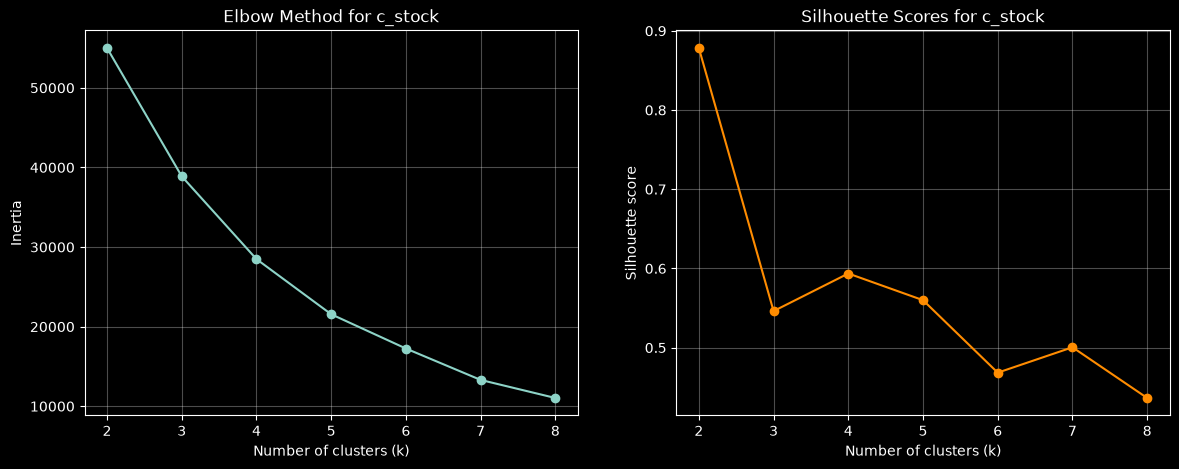

{2: 0.8783, 3: 0.5461, 4: 0.5936, 5: 0.5599, 6: 0.4684, 7: 0.5005, 8: 0.4364}
Best silhouette score: k=2
Selected clusters: 2


In [33]:
stock_data = pd.read_csv(CLEAN_DIR / "c_stock.csv")

# Use numeric market features; symbol and date identify rows but are not clustering features.
features = ["open", "high", "low", "close", "volume"]
X = stock_data[features].dropna()

# Standardization prevents volume and price scale from dominating the distance calculation.
#We pick 20000 random samples to speed up the clustering process and avoid memory issues.
X_sample = X.sample(n=20000, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

# Calculate inertia and silhouette scores for several k values.
k_values = range(2, 9)
inertias = []
silhouette_scores = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels, metric="euclidean"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method for c_stock")
axes[0].set_xticks(list(k_values))
axes[0].grid(alpha=0.3)

axes[1].plot(list(k_values), silhouette_scores, marker="o", color="darkorange")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
axes[1].set_title("Silhouette Scores for c_stock")
axes[1].set_xticks(list(k_values))
axes[1].grid(alpha=0.3)
plt.show()

best_k = list(k_values)[silhouette_scores.index(max(silhouette_scores))]
print(dict(zip(k_values, [round(value, 4) for value in silhouette_scores])))
print(f"Best silhouette score: k={best_k}")

# k=4 is selected as a practical balance between separation and useful detail.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)
print(f"Selected clusters: {best_k}")

In [46]:
# We create the model object and fit it to the scaled data. The model is then used to predict cluster labels for each data point, which are added to the original DataFrame for further analysis.
model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels = model.fit_predict(X_scaled)

np.unique(labels, return_counts=True)
X_sample["cluster_label"] = labels

# We calculate the mean values of each feature for each cluster to understand the characteristics of each cluster and naming them accordingly. This helps in interpreting the clusters and their significance in the context of stock market data.
cluster_means = X_sample.groupby("cluster_label").mean()
#rename the row index according to the cluster label
cluster_means.index = [f"Cluster {i+1}" for i in cluster_means.index]

display(cluster_means)

,open,high,low,close,volume
Cluster 1,705.187690,711.641528,698.512874,705.197012,1.298321e+06
Cluster 2,76.756626,77.451137,76.040250,76.761121,4.316221e+06


Text(0.5, 1.0, 'K-Means Clustering of Stock Data (High vs Low Price)')

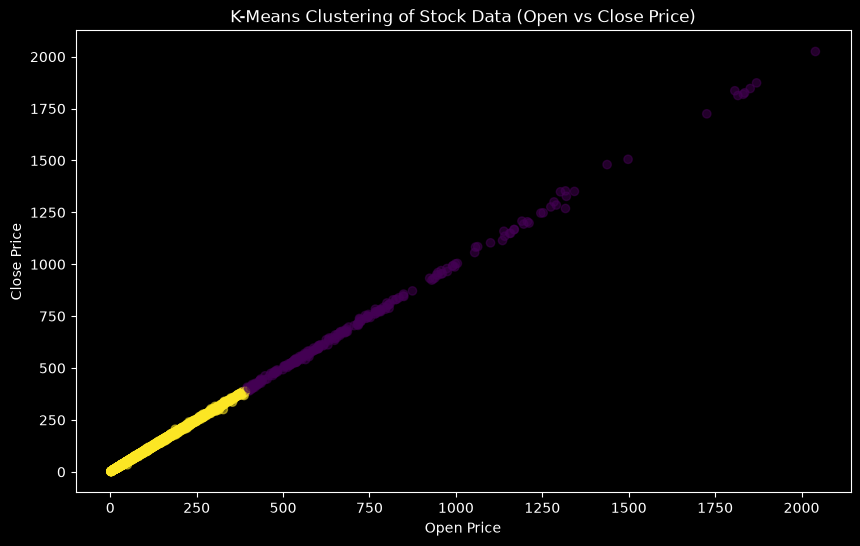

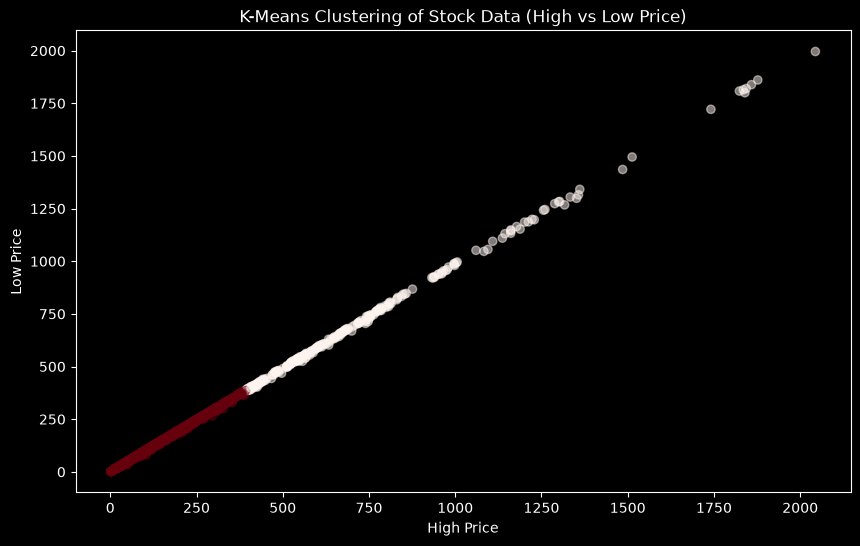

In [50]:
#Visualize the clusters using a scatter plot of two features, with points colored by their cluster label. This provides a visual representation of how the data points are grouped into clusters based on the selected features.
plt.figure(figsize=(10, 6))
plt.scatter(X_sample["open"], X_sample["close"], c=X_sample["cluster_label"], cmap="viridis", alpha=0.5)
plt.xlabel("Open Price")
plt.ylabel("Close Price")
plt.title("K-Means Clustering of Stock Data (Open vs Close Price)")

plt.figure(figsize=(10, 6))
plt.scatter(X_sample["high"], X_sample["low"], c=X_sample["cluster_label"], cmap="Reds", alpha=0.5)
plt.xlabel("High Price")
plt.ylabel("Low Price")
plt.title("K-Means Clustering of Stock Data (High vs Low Price)")